In [1]:
!pip install shap alibi scikit-image -q
!pip install transformers==4.41.2 tf-keras xgboost scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 19.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 76.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transforme

In [2]:
%%writefile config.py
import os

# --- MASTER PATHS ---
BASE_DATA_PATH = "/kaggle/input/datasets/artechie001/cfdf-preprocessed-dataset-non-splited/CelebDF_dataset_split" 
TRAIN_PATH = os.path.join(BASE_DATA_PATH, "train")
VAL_PATH = os.path.join(BASE_DATA_PATH, "val")
TEST_PATH = os.path.join(BASE_DATA_PATH, "test")

# --- HYPERPARAMETERS ---
IMG_SIZE = (224, 224)
BATCH_SIZE_PER_REPLICA = 32 
EPOCHS = 20
LEARNING_RATE = 1e-4
DATA_SUBSET_RATIO = 0.99  

# --- MODEL WEIGHTS ---
VIT_WEIGHTS_FILE = "/kaggle/input/models/artechie001/celeb-df-models-final/tensorflow2/default/1/vit_best.weights.h5"
XCP_ATTN_WEIGHTS_FILE = "xcp_attn_best.weights.h5"
XCP_BASE_WEIGHTS_FILE = "xcp_base_best.weights.h5"
EFFB5_WEIGHTS_FILE = "/kaggle/input/models/artechie001/celeb-df-models-final/tensorflow2/default/1/effb5_best.weights.h5"
DENSE_WEIGHTS_FILE = "dense201_best.weights.h5"

# --- FEATURE EXTRACTION PATHS ---
FEATURE_DIR = "/kaggle/input/datasets/artechie001/cfdf-db5-vit-features/Features_cfdf"
MASK_FILE = "/kaggle/input/datasets/artechie001/optimised-features/feature_mask.npy"
XGB_MODEL_FILE = "/kaggle/input/datasets/artechie001/optimised-features/final_xgboost_model.pkl"

Writing config.py


In [3]:
%%writefile utils.py
import config
import os
import glob
import tensorflow as tf
from sklearn.utils import shuffle

def get_image_paths(data_path, subset_ratio=config.DATA_SUBSET_RATIO):
    """
    Retrieves and shuffles image paths from the nested directory structure.
    """
    fake_paths = glob.glob(os.path.join(data_path, 'fake', '*', '*.*'))
    real_paths = glob.glob(os.path.join(data_path, 'real', '*', '*.*'))
    
    paths = fake_paths + real_paths
    labels = [1] * len(fake_paths) + [0] * len(real_paths) # 1 for Fake, 0 for Real
    
    paths, labels = shuffle(paths, labels, random_state=42)
    
    if subset_ratio < 1.0:
        limit = int(len(paths) * subset_ratio)
        paths = paths[:limit]
        labels = labels[:limit]
        
    print(f"Loaded {len(paths)} images from {data_path}")
    return paths, labels

def load_and_preprocess_image(path, label):
    """
    Native TensorFlow function to read, decode, resize, and normalize images.
    Crucial for preventing CPU bottlenecks during multi-GPU training.
    """

    img = tf.io.read_file(path)

    img = tf.image.decode_image(img, channels=3, expand_animations=False)

    img = tf.image.resize(img, config.IMG_SIZE)

    img = tf.cast(img, tf.float32) / 255.0
    

    label = tf.one_hot(label, depth=2)
    
    return img, label

def create_tf_dataset(paths, labels, batch_size, is_training=True):
    """
    Builds a highly optimized tf.data.Dataset pipeline.
    Uses AUTOTUNE to dynamically allocate CPU threads for data loading.
    """

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if is_training:

        dataset = dataset.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
        

    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    

    dataset = dataset.batch(batch_size)
    

    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

Writing utils.py


In [4]:
%%writefile models.py
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import Xception, EfficientNetB5, DenseNet201
from transformers import TFViTModel
from tensorflow.keras import mixed_precision

# Ensure final layers output in float32 for mixed precision stability
FINAL_DTYPE = 'float32'

class ViTWrapper(layers.Layer):
    """Custom layer to wrap the HuggingFace ViT model natively into Keras."""
    def __init__(self, vit_model, **kwargs):
        super().__init__(**kwargs)
        self.vit_model = vit_model
        
    def call(self, inputs):
        x = tf.transpose(inputs, perm=[0, 3, 1, 2])
        outputs = self.vit_model.vit(pixel_values=x)
        return outputs.last_hidden_state[:, 0, :]
        
    def get_config(self):
        return super().get_config()

class AttentionLayer(layers.Layer):
    """Custom Attention Mechanism for feature weighting."""
    def __init__(self, dim, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        self.dim = dim
        
    def get_config(self):
        config = super().get_config()
        config.update({"dim": self.dim})
        return config
        
    def build(self, input_shape):
        self.dense = layers.Dense(self.dim, activation='tanh', use_bias=True)
        self.u_vec = self.add_weight(name='u_vec', shape=(self.dim, 1), initializer='uniform', trainable=True)
        super(AttentionLayer, self).build(input_shape)
        
    def call(self, x):
        u_it = self.dense(x)
        score = tf.matmul(u_it, self.u_vec)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

# 1. ViT
def build_vit_classifier(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    norm_layer = layers.Normalization(mean=[0.485, 0.456, 0.406], variance=[0.229**2, 0.224**2, 0.225**2])
    x = norm_layer(inputs)
    try:
        vit_model = TFViTModel.from_pretrained('google/vit-base-patch16-224', from_pt=True)
    except:
        vit_model = TFViTModel.from_pretrained('google/vit-base-patch16-224')
    vit_model.trainable = True
    features = ViTWrapper(vit_model, name='vit_features')(x)
    x = layers.Dense(512, activation='relu')(features)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(2, activation='softmax', dtype=FINAL_DTYPE)(x)
    return Model(inputs, outputs, name="ViT_Classifier")

# 2. Xception + Custom Attention
def build_xception_attn_classifier(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(scale=2.0, offset=-1.0)(inputs) 
    x = layers.GaussianNoise(0.05)(x)
    base = Xception(include_top=False, weights='imagenet', input_tensor=x)
    base.trainable = True
    x = base.output
    x = layers.Reshape((x.shape[1]*x.shape[2], x.shape[3]))(x)
    features = AttentionLayer(dim=512, name='xcp_features')(x)
    x = layers.Dense(512, activation='relu')(features)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(2, activation='softmax', dtype=FINAL_DTYPE)(x)
    return Model(inputs, outputs, name="Xception_Attn_Classifier")

# 3. Base Xception
def build_xception_base_classifier(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(scale=2.0, offset=-1.0)(inputs) 
    base = Xception(include_top=False, weights='imagenet', input_tensor=x, pooling='avg')
    base.trainable = True
    x = base.output
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(2, activation='softmax', dtype=FINAL_DTYPE)(x)
    return Model(inputs, outputs, name="Xception_Base_Classifier")

# 4. EfficientNetB5
def build_effb5_classifier(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(scale=255.0)(inputs) 
    
    # --- BULLETPROOF WORKAROUND FOR EFFICIENTNET ---
    # Temporarily drop back to float32 to bypass the internal hardcoded constants bug
    current_policy = mixed_precision.global_policy()
    mixed_precision.set_global_policy('float32')
    
    base = EfficientNetB5(include_top=False, weights='imagenet', pooling='avg')
    
    # Immediately restore the mixed precision policy
    mixed_precision.set_global_policy(current_policy)
    # -----------------------------------------------
    
    # Explicitly force input to float32 before feeding it to the base model
    x = tf.cast(x, tf.float32)
    x = base(x)
    
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(2, activation='softmax', dtype=FINAL_DTYPE)(x)
    return Model(inputs, outputs, name="EfficientNetB5_Classifier")

# 5. DenseNet201
def build_dense201_classifier(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(scale=255.0)(inputs) 
    
    # Apply standard preprocessing
    x = tf.cast(x, tf.float32)
    x = tf.keras.applications.densenet.preprocess_input(x) 
    
    # Apply the same safety wrapper for DenseNet
    current_policy = mixed_precision.global_policy()
    mixed_precision.set_global_policy('float32')
    
    base = DenseNet201(include_top=False, weights='imagenet', pooling='avg')
    
    mixed_precision.set_global_policy(current_policy)
    
    x = base(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(2, activation='softmax', dtype=FINAL_DTYPE)(x)
    return Model(inputs, outputs, name="DenseNet201_Classifier")

Writing models.py


# Grad-CAM++

In [5]:
%%writefile xai_2_gradcam_plus.py
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

from models import build_effb5_classifier, build_vit_classifier
import config
from utils import get_image_paths

def get_effb5_gradcam_plus(img_tensor, model, class_idx=1):
    """
    Computes Grad-CAM++ using a hardcoded forward pass to perfectly 
    match models.py and bypass the TFOpLambda/Graph Disconnected bugs.
    """
    base = model.get_layer('efficientnetb5')
    
    # 1. Isolate the spatial feature extractor
    conv_model = tf.keras.models.Model(inputs=base.input, outputs=base.get_layer('top_activation').output)
    
    # 2. Extract the specific classifier head layers from models.py
    dense_1 = model.layers[-3]  # Dense(512)
    dropout = model.layers[-2]  # Dropout(0.4)
    dense_2 = model.layers[-1]  # Dense(2)
    
    # 3. Manually apply the Rescaling and Casting
    x = img_tensor * 255.0
    x = tf.cast(x, tf.float32)
    
    with tf.GradientTape() as tape3:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape1:
                
                # 4. Get the spatial features
                conv_outputs = conv_model(x)
                tape1.watch(conv_outputs)
                tape2.watch(conv_outputs)
                tape3.watch(conv_outputs)
                
                # 5. Apply the rest of the model (Pooling + Classifier Head)
                x_pool = tf.keras.layers.GlobalAveragePooling2D()(conv_outputs)
                x_head = dense_1(x_pool)
                x_head = dropout(x_head, training=False)
                predictions = dense_2(x_head)
                
                loss = predictions[:, class_idx]
                
            first_grads = tape1.gradient(loss, conv_outputs)
        second_grads = tape2.gradient(first_grads, conv_outputs)
    third_grads = tape3.gradient(second_grads, conv_outputs)
    
    # Safety Check: Fallback to standard Grad-CAM if ReLUs destroy higher-order gradients
    if second_grads is None or third_grads is None:
        pooled_grads = tf.reduce_mean(first_grads, axis=(0, 1, 2))
        heatmap = tf.reduce_sum(pooled_grads * conv_outputs[0], axis=-1)
    else:
        global_sum = tf.reduce_sum(conv_outputs, axis=(0, 1, 2))
        alpha_num = second_grads
        alpha_denom = 2.0 * second_grads + third_grads * global_sum[tf.newaxis, tf.newaxis, tf.newaxis, :]
        alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom))
        
        alphas = alpha_num / alpha_denom
        weights = tf.maximum(first_grads, 0.0)
        alphas_norm = tf.reduce_sum(alphas, axis=(1, 2), keepdims=True)
        alphas /= (alphas_norm + 1e-7)
        
        deep_weights = tf.reduce_sum(alphas * weights, axis=(1, 2))
        heatmap = tf.reduce_sum(deep_weights[:, tf.newaxis, tf.newaxis, :] * conv_outputs, axis=-1)[0]
        
    heatmap = tf.maximum(heatmap, 0).numpy()
    if np.max(heatmap) != 0: 
        heatmap /= np.max(heatmap)
        
    return heatmap

def get_vit_gradcam_plus(img_tensor, model, class_idx=1):
    img_var = tf.Variable(img_tensor)
    with tf.GradientTape() as tape:
        predictions = model(img_var)
        loss = predictions[:, class_idx]
    
    grads = tape.gradient(loss, img_var)[0]
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)
    saliency = tf.image.resize(saliency[tf.newaxis, ..., tf.newaxis], (14, 14))[0, :, :, 0].numpy()
    
    vit_base = model.get_layer('vit_features').vit_model.vit
    outputs = vit_base(pixel_values=tf.transpose(img_tensor, perm=[0, 3, 1, 2]), output_attentions=True)
    attn = tf.reduce_mean(outputs.attentions[-1], axis=1)[0, 0, 1:]
    attn_map = tf.reshape(attn, (14, 14)).numpy()
    
    heatmap = saliency * attn_map
    return (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-7)

def main():
    print("Loading Models for Grad-CAM++...")
    model_eff = build_effb5_classifier()
    model_eff.load_weights(config.EFFB5_WEIGHTS_FILE)
    model_vit = build_vit_classifier()
    model_vit.load_weights(config.VIT_WEIGHTS_FILE)
    
    paths, labels = get_image_paths(config.TEST_PATH, subset_ratio=1.0)
    fake_paths = [p for p, l in zip(paths, labels) if l == 1][:3]
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    titles = ["Original Frame", "EffNet (Grad-CAM++)", "ViT (Grad-CAM++)", "Hybrid Fused"]
    
    for row_idx, path in enumerate(fake_paths):
        print(f"Processing Image {row_idx + 1}/3...")
        img_raw = cv2.resize(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB), config.IMG_SIZE)
        img_tensor = np.expand_dims(img_raw.astype(np.float32) / 255.0, axis=0)
        
        hm_eff = cv2.resize(get_effb5_gradcam_plus(img_tensor, model_eff), (224, 224))
        hm_vit = cv2.resize(get_vit_gradcam_plus(img_tensor, model_vit), (224, 224))
        hm_hybrid = np.maximum(hm_eff, hm_vit)
        
        maps = [None, hm_eff, hm_vit, hm_hybrid]
        for col_idx in range(4):
            ax = axes[row_idx, col_idx]
            if col_idx == 0: 
                ax.imshow(img_raw)
            else:
                colored = cv2.applyColorMap(np.uint8(255 * maps[col_idx]), cv2.COLORMAP_JET)
                ax.imshow(cv2.addWeighted(img_raw, 0.6, colored, 0.4, 0))
            if row_idx == 0: 
                ax.set_title(titles[col_idx], fontweight='bold', fontsize=16, pad=15)
            ax.axis('off')
            
    plt.tight_layout()
    plt.savefig('xai_2_gradcam_plus.png')
    print("Success: Saved 'xai_2_gradcam_plus.png'")

if __name__ == "__main__":
    main()

Writing xai_2_gradcam_plus.py


In [6]:
!python xai_2_gradcam_plus.py

2026-06-01 19:00:19.731705: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780340419.976993      60 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780340420.043249      60 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780340420.635664      60 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780340420.635737      60 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780340420.635752      60 computation_placer.cc:177] computation placer alr

# SmoothGrad-CAM

In [7]:
%%writefile xai_4_smoothgrad.py
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

from models import build_effb5_classifier, build_vit_classifier
import config
from utils import get_image_paths

def get_effb5_smoothgrad(img_tensor, model, class_idx=1, samples=500, noise_level=0.1):
    stdev = noise_level * (tf.reduce_max(img_tensor) - tf.reduce_min(img_tensor))
    total_gradients = tf.zeros_like(img_tensor)
    
    for _ in range(samples):
        noise = tf.random.normal(shape=tf.shape(img_tensor), mean=0.0, stddev=stdev)
        noisy_img = tf.Variable(img_tensor + noise)
        
        with tf.GradientTape() as tape:
            predictions = model(noisy_img, training=False)
            loss = predictions[:, class_idx]
            
        grad = tape.gradient(loss, noisy_img)
        total_gradients += grad
        
    avg_grads = total_gradients / samples
    heatmap = tf.reduce_max(tf.abs(avg_grads), axis=-1)[0].numpy()
    return (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-7)

def get_vit_smoothgrad(img_tensor, model, class_idx=1, samples=50, noise_level=0.1):
    stdev = noise_level * (tf.reduce_max(img_tensor) - tf.reduce_min(img_tensor))
    total_gradients = tf.zeros_like(img_tensor)
    
    for _ in range(samples):
        noise = tf.random.normal(shape=tf.shape(img_tensor), mean=0.0, stddev=stdev)
        noisy_img = tf.Variable(img_tensor + noise)
        
        with tf.GradientTape() as tape:
            predictions = model(noisy_img, training=False)
            loss = predictions[:, class_idx]
            
        grad = tape.gradient(loss, noisy_img)
        total_gradients += grad
        
    avg_grads = total_gradients / samples
    
    # THE FIX: Safely expand to 4D for resizing
    saliency = tf.reduce_max(tf.abs(avg_grads), axis=-1)
    saliency = tf.expand_dims(saliency, axis=-1)
    saliency = tf.image.resize(saliency, (14, 14))[0, :, :, 0].numpy()
    
    vit_base = model.get_layer('vit_features').vit_model.vit
    outputs = vit_base(pixel_values=tf.transpose(img_tensor, perm=[0, 3, 1, 2]), output_attentions=True)
    attn = tf.reduce_mean(outputs.attentions[-1], axis=1)[0, 0, 1:]
    attn_map = tf.reshape(attn, (14, 14)).numpy()
    
    heatmap = saliency * attn_map
    return (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-7)

def main():
    print("Loading Models for SmoothGrad...")
    model_eff = build_effb5_classifier()
    model_eff.load_weights(config.EFFB5_WEIGHTS_FILE)
    model_vit = build_vit_classifier()
    model_vit.load_weights(config.VIT_WEIGHTS_FILE)
    
    paths, labels = get_image_paths(config.TEST_PATH, subset_ratio=1.0)
    fake_paths = [p for p, l in zip(paths, labels) if l == 1][:3]
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    titles = ["Original Frame", "EffNet (SmoothGrad)", "ViT (SmoothGrad)", "Hybrid Fused"]
    
    for row_idx, path in enumerate(fake_paths):
        print(f"Processing Image {row_idx + 1}/3...")
        img_raw = cv2.resize(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB), config.IMG_SIZE)
        img_tensor = np.expand_dims(img_raw.astype(np.float32) / 255.0, axis=0)
        
        hm_eff = cv2.resize(get_effb5_smoothgrad(img_tensor, model_eff), (224, 224))
        hm_vit = cv2.resize(get_vit_smoothgrad(img_tensor, model_vit), (224, 224))
        hm_hybrid = np.maximum(hm_eff, hm_vit)
        
        maps = [None, hm_eff, hm_vit, hm_hybrid]
        for col_idx in range(4):
            ax = axes[row_idx, col_idx]
            if col_idx == 0: 
                ax.imshow(img_raw)
            else:
                colored = cv2.applyColorMap(np.uint8(255 * maps[col_idx]), cv2.COLORMAP_JET)
                ax.imshow(cv2.addWeighted(img_raw, 0.6, colored, 0.4, 0))
            if row_idx == 0: 
                ax.set_title(titles[col_idx], fontweight='bold', fontsize=16, pad=15)
            ax.axis('off')
            
    plt.tight_layout()
    plt.savefig('xai_4_smoothgrad_grid.png')
    print("Success: Saved 'xai_4_smoothgrad_grid.png'")

if __name__ == "__main__":
    main()

Writing xai_4_smoothgrad.py


In [8]:
!python xai_4_smoothgrad.py

2026-06-01 19:01:33.272461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780340493.294607     507 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780340493.301775     507 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780340493.320607     507 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780340493.320633     507 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780340493.320637     507 computation_placer.cc:177] computation placer alr

# Integrated Gradients

In [9]:
%%writefile xai_5_ig.py
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

from models import build_effb5_classifier, build_vit_classifier
import config
from utils import get_image_paths

def get_effb5_integrated_gradients(img_tensor, model, class_idx=1, steps=500):
    baseline = tf.zeros_like(img_tensor)
    alphas = tf.linspace(start=0.0, stop=1.0, num=steps+1)
    alphas_x = alphas[:, tf.newaxis, tf.newaxis, tf.newaxis]
    interpolated = baseline + alphas_x * (img_tensor - baseline)
    
    gradient_tensors = []
    for i in range(steps + 1):
        step_img = tf.Variable(interpolated[i:i+1])
        with tf.GradientTape() as tape:
            predictions = model(step_img, training=False)
            loss = predictions[:, class_idx]
        grad = tape.gradient(loss, step_img)
        gradient_tensors.append(grad)
        
    grads = tf.concat(gradient_tensors, axis=0)
    avg_grads = tf.reduce_mean(grads[:-1], axis=0, keepdims=True)
    integrated_grads = (img_tensor - baseline) * avg_grads
    
    heatmap = tf.reduce_max(tf.abs(integrated_grads), axis=-1)[0].numpy()
    return (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-7)

def get_vit_integrated_gradients(img_tensor, model, class_idx=1, steps=50):
    baseline = tf.zeros_like(img_tensor)
    alphas = tf.linspace(start=0.0, stop=1.0, num=steps+1)
    alphas_x = alphas[:, tf.newaxis, tf.newaxis, tf.newaxis]
    interpolated = baseline + alphas_x * (img_tensor - baseline)
    
    gradient_tensors = []
    for i in range(steps + 1):
        step_img = tf.Variable(interpolated[i:i+1])
        with tf.GradientTape() as tape:
            predictions = model(step_img, training=False)
            loss = predictions[:, class_idx]
        grad = tape.gradient(loss, step_img)
        gradient_tensors.append(grad)
        
    grads = tf.concat(gradient_tensors, axis=0)
    avg_grads = tf.reduce_mean(grads[:-1], axis=0, keepdims=True)
    integrated_grads = (img_tensor - baseline) * avg_grads
    
    # THE FIX: Safely expand to 4D for resizing
    saliency = tf.reduce_max(tf.abs(integrated_grads), axis=-1)
    saliency = tf.expand_dims(saliency, axis=-1)
    saliency = tf.image.resize(saliency, (14, 14))[0, :, :, 0].numpy()
    
    vit_base = model.get_layer('vit_features').vit_model.vit
    outputs = vit_base(pixel_values=tf.transpose(img_tensor, perm=[0, 3, 1, 2]), output_attentions=True)
    attn = tf.reduce_mean(outputs.attentions[-1], axis=1)[0, 0, 1:]
    attn_map = tf.reshape(attn, (14, 14)).numpy()
    
    heatmap = saliency * attn_map
    return (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-7)

def main():
    print("Loading Models for Integrated Gradients...")
    model_eff = build_effb5_classifier()
    model_eff.load_weights(config.EFFB5_WEIGHTS_FILE)
    model_vit = build_vit_classifier()
    model_vit.load_weights(config.VIT_WEIGHTS_FILE)
    
    paths, labels = get_image_paths(config.TEST_PATH, subset_ratio=1.0)
    fake_paths = [p for p, l in zip(paths, labels) if l == 1][:3]
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    titles = ["Original Frame", "EffNet (IG)", "ViT (IG)", "Hybrid Fused"]
    
    for row_idx, path in enumerate(fake_paths):
        print(f"Processing Image {row_idx + 1}/3...")
        img_raw = cv2.resize(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB), config.IMG_SIZE)
        img_tensor = np.expand_dims(img_raw.astype(np.float32) / 255.0, axis=0)
        
        hm_eff = cv2.resize(get_effb5_integrated_gradients(img_tensor, model_eff), (224, 224))
        hm_vit = cv2.resize(get_vit_integrated_gradients(img_tensor, model_vit), (224, 224))
        hm_hybrid = np.maximum(hm_eff, hm_vit)
        
        maps = [None, hm_eff, hm_vit, hm_hybrid]
        for col_idx in range(4):
            ax = axes[row_idx, col_idx]
            if col_idx == 0: 
                ax.imshow(img_raw)
            else:
                colored = cv2.applyColorMap(np.uint8(255 * maps[col_idx]), cv2.COLORMAP_JET)
                ax.imshow(cv2.addWeighted(img_raw, 0.6, colored, 0.4, 0))
            if row_idx == 0: 
                ax.set_title(titles[col_idx], fontweight='bold', fontsize=16, pad=15)
            ax.axis('off')
            
    plt.tight_layout()
    plt.savefig('xai_5_ig_grid.png')
    print("Success: Saved 'xai_5_ig_grid.png'")

if __name__ == "__main__":
    main()

Writing xai_5_ig.py


In [10]:
!python  xai_5_ig.py

2026-06-01 19:20:25.572552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780341625.595630     613 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780341625.603447     613 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780341625.622956     613 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780341625.622984     613 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780341625.622988     613 computation_placer.cc:177] computation placer alr

In [11]:
%%writefile xai_3_vit_attention.py
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

from models import build_vit_classifier
import config
from utils import get_image_paths

def get_vit_attention(img_tensor, model):
    vit_base = model.get_layer('vit_features').vit_model.vit
    outputs = vit_base(pixel_values=tf.transpose(img_tensor, perm=[0, 3, 1, 2]), output_attentions=True)
    attn = tf.reduce_mean(outputs.attentions[-1], axis=1)[0, 0, 1:]
    heatmap = tf.reshape(attn, (14, 14)).numpy()
    return (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-7)

def main():
    model_vit = build_vit_classifier()
    model_vit.load_weights(config.VIT_WEIGHTS_FILE)
    
    paths, labels = get_image_paths(config.TEST_PATH, subset_ratio=1.0)
    fake_paths = [p for p, l in zip(paths, labels) if l == 1][:3]
    
    fig, axes = plt.subplots(3, 2, figsize=(10, 15))
    titles = ["Original Frame", "ViT (Self-Attention)"]
    
    for row_idx, path in enumerate(fake_paths):
        img_raw = cv2.resize(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB), config.IMG_SIZE)
        img_tensor = np.expand_dims(img_raw.astype(np.float32) / 255.0, axis=0)
        
        hm_vit = cv2.resize(get_vit_attention(img_tensor, model_vit), (224, 224))
        colored = cv2.applyColorMap(np.uint8(255 * hm_vit), cv2.COLORMAP_JET)
        
        axes[row_idx, 0].imshow(img_raw)
        axes[row_idx, 1].imshow(cv2.addWeighted(img_raw, 0.6, colored, 0.4, 0))
        
        if row_idx == 0:
            axes[row_idx, 0].set_title(titles[0], fontweight='bold')
            axes[row_idx, 1].set_title(titles[1], fontweight='bold')
            
        axes[row_idx, 0].axis('off')
        axes[row_idx, 1].axis('off')
            
    plt.tight_layout()
    plt.savefig('xai_3_vit_attention.png')

if __name__ == "__main__":
    main()

Writing xai_3_vit_attention.py


In [12]:
!python xai_3_vit_attention.py

2026-06-01 19:39:15.820709: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780342755.844557     732 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780342755.853556     732 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780342755.873528     732 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780342755.873555     732 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780342755.873559     732 computation_placer.cc:177] computation placer alr

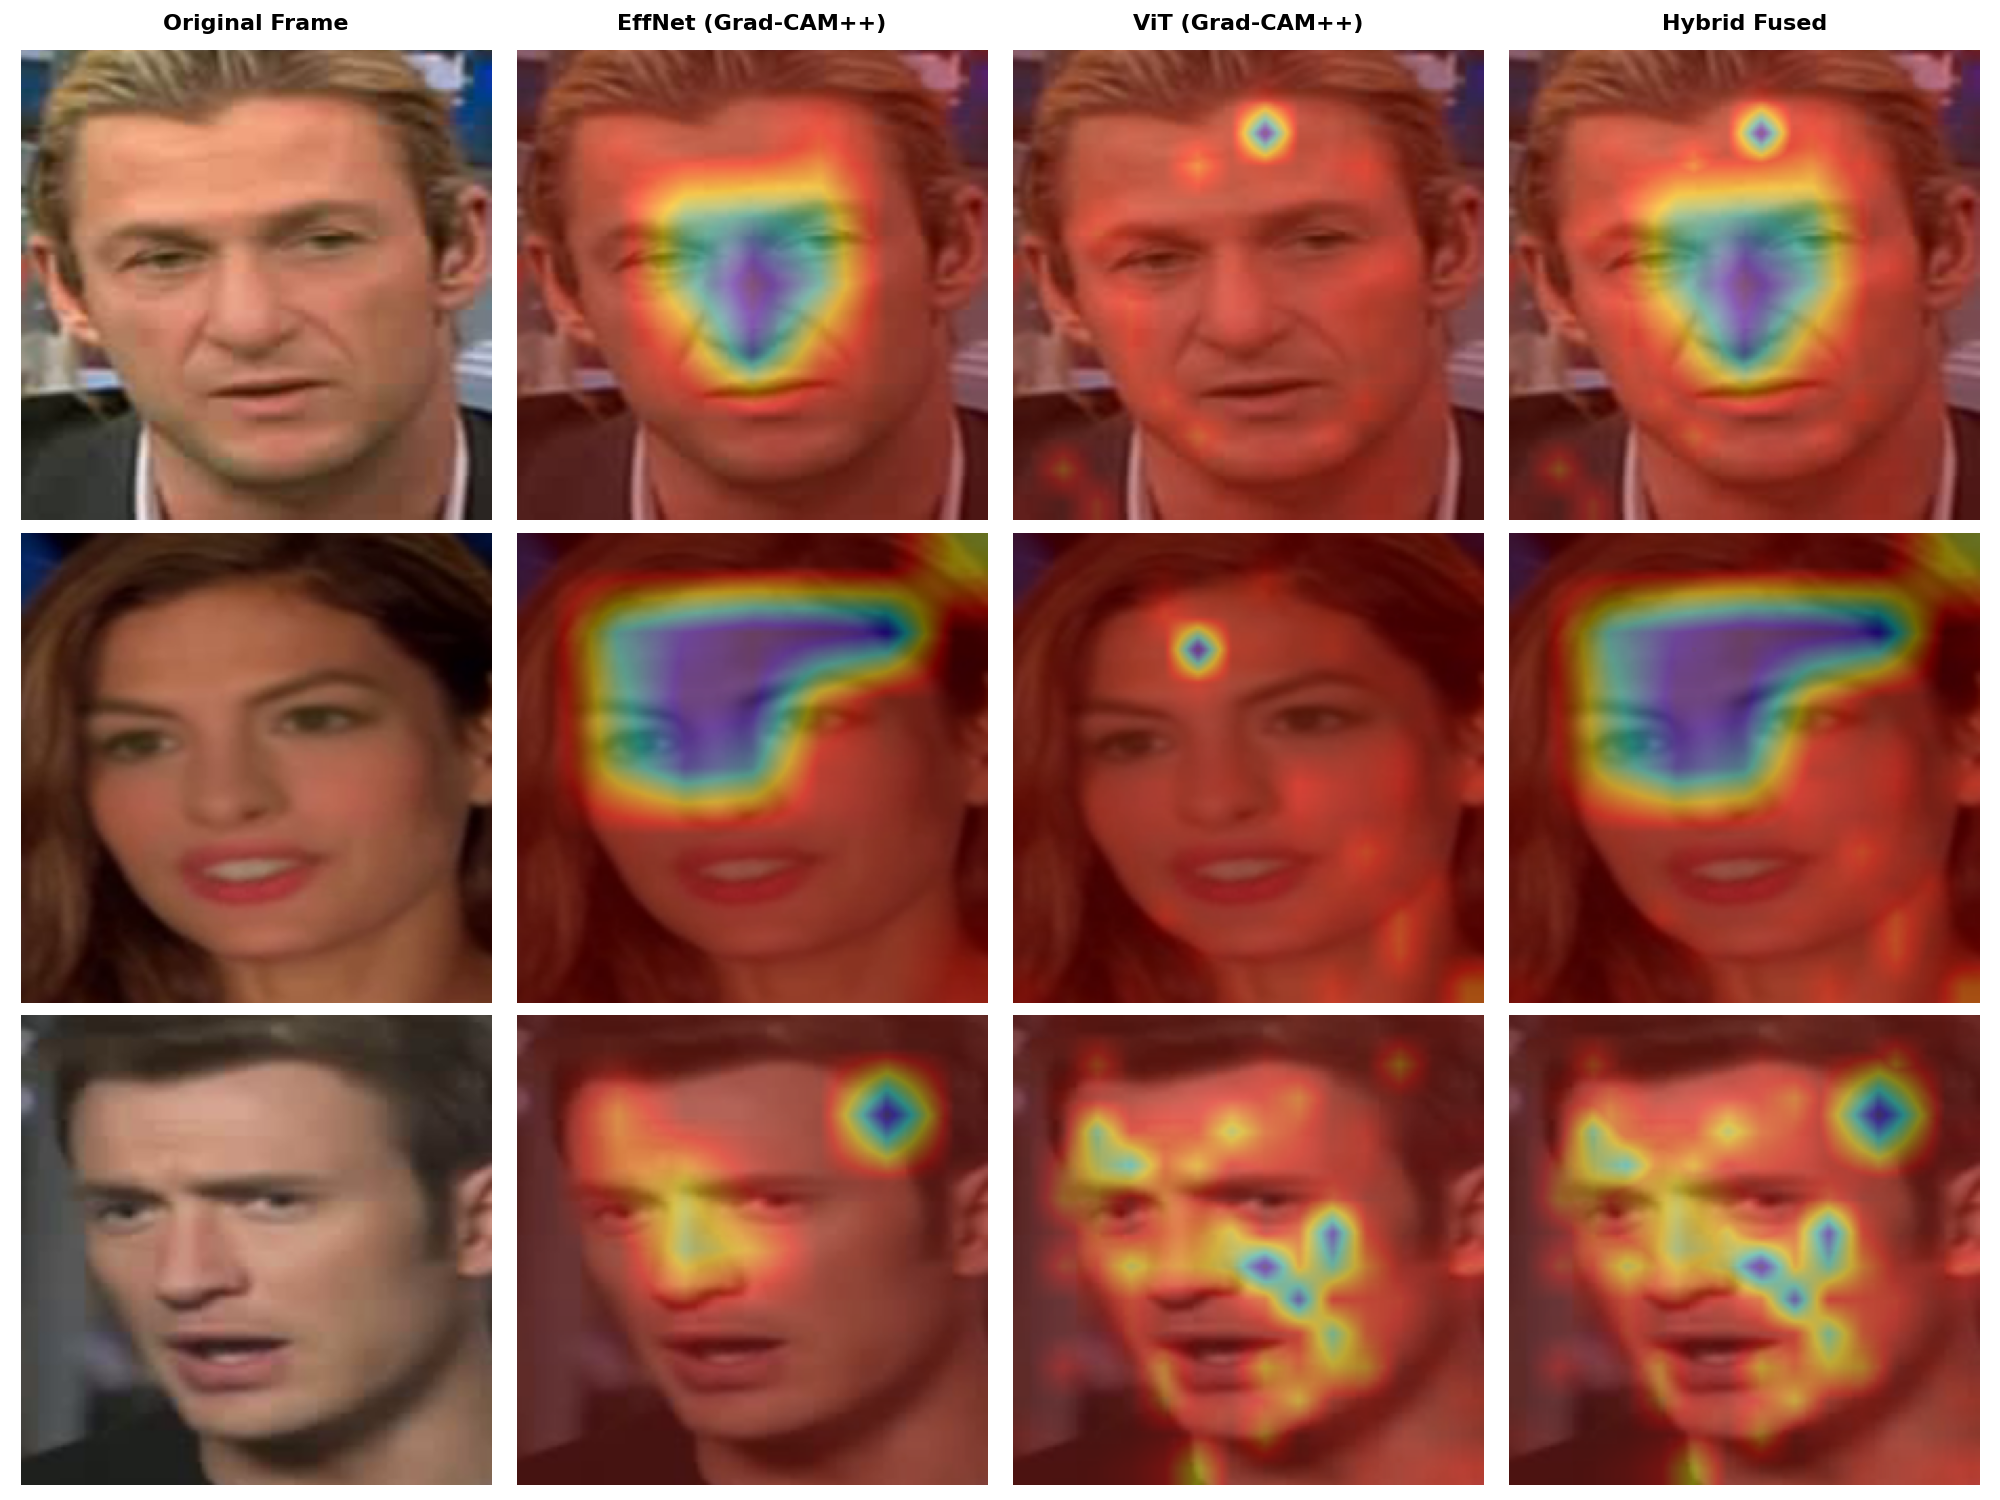

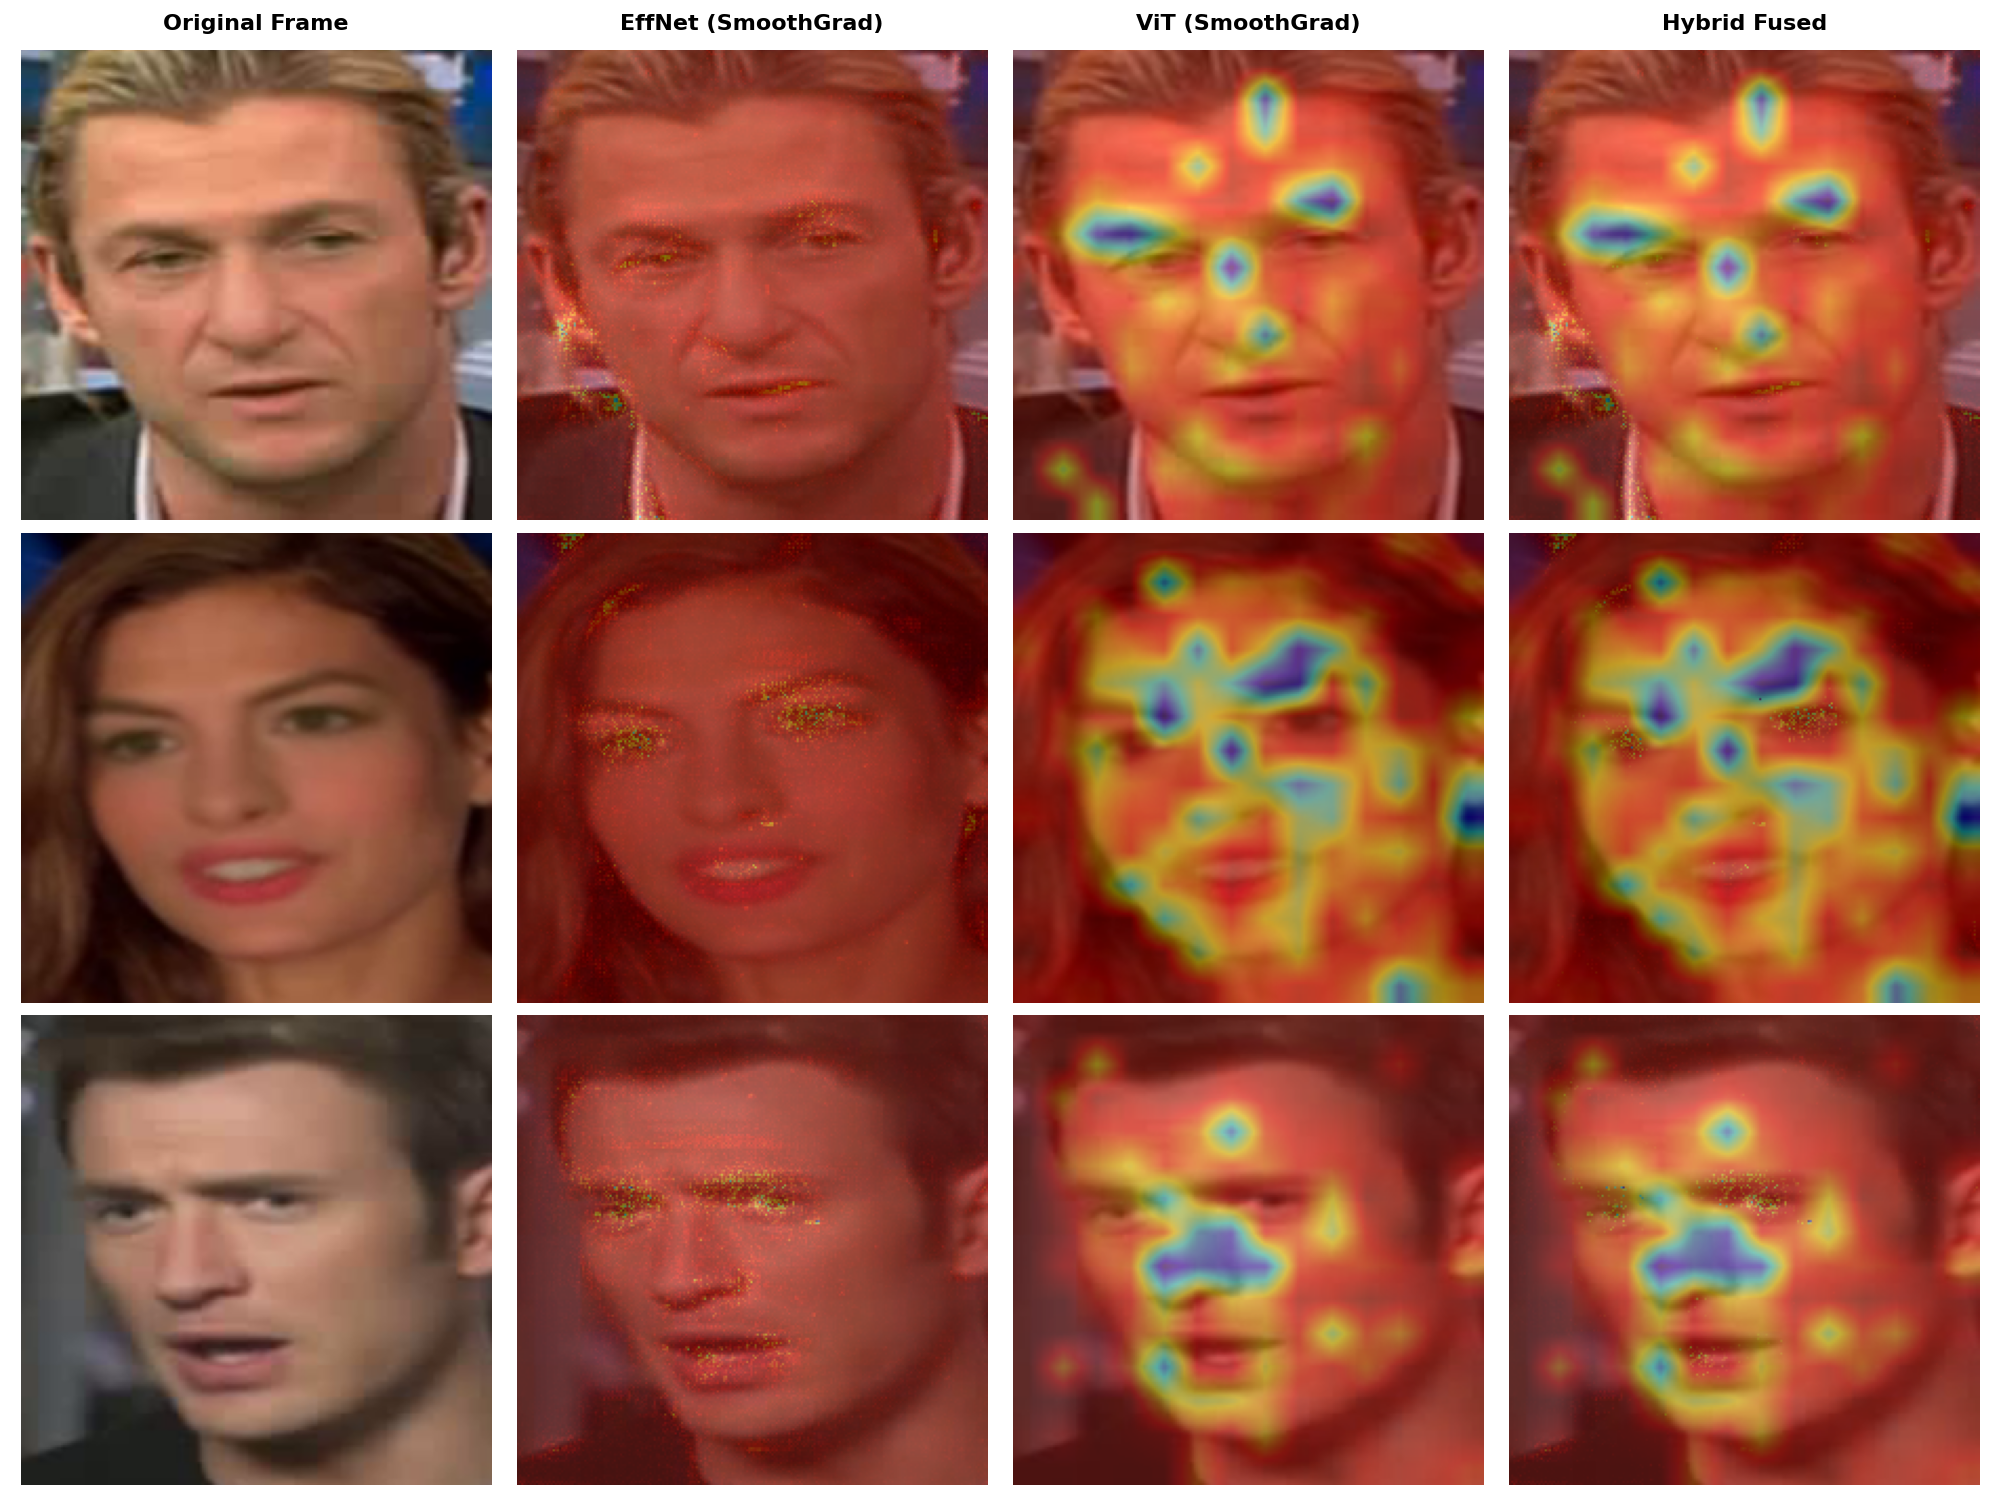

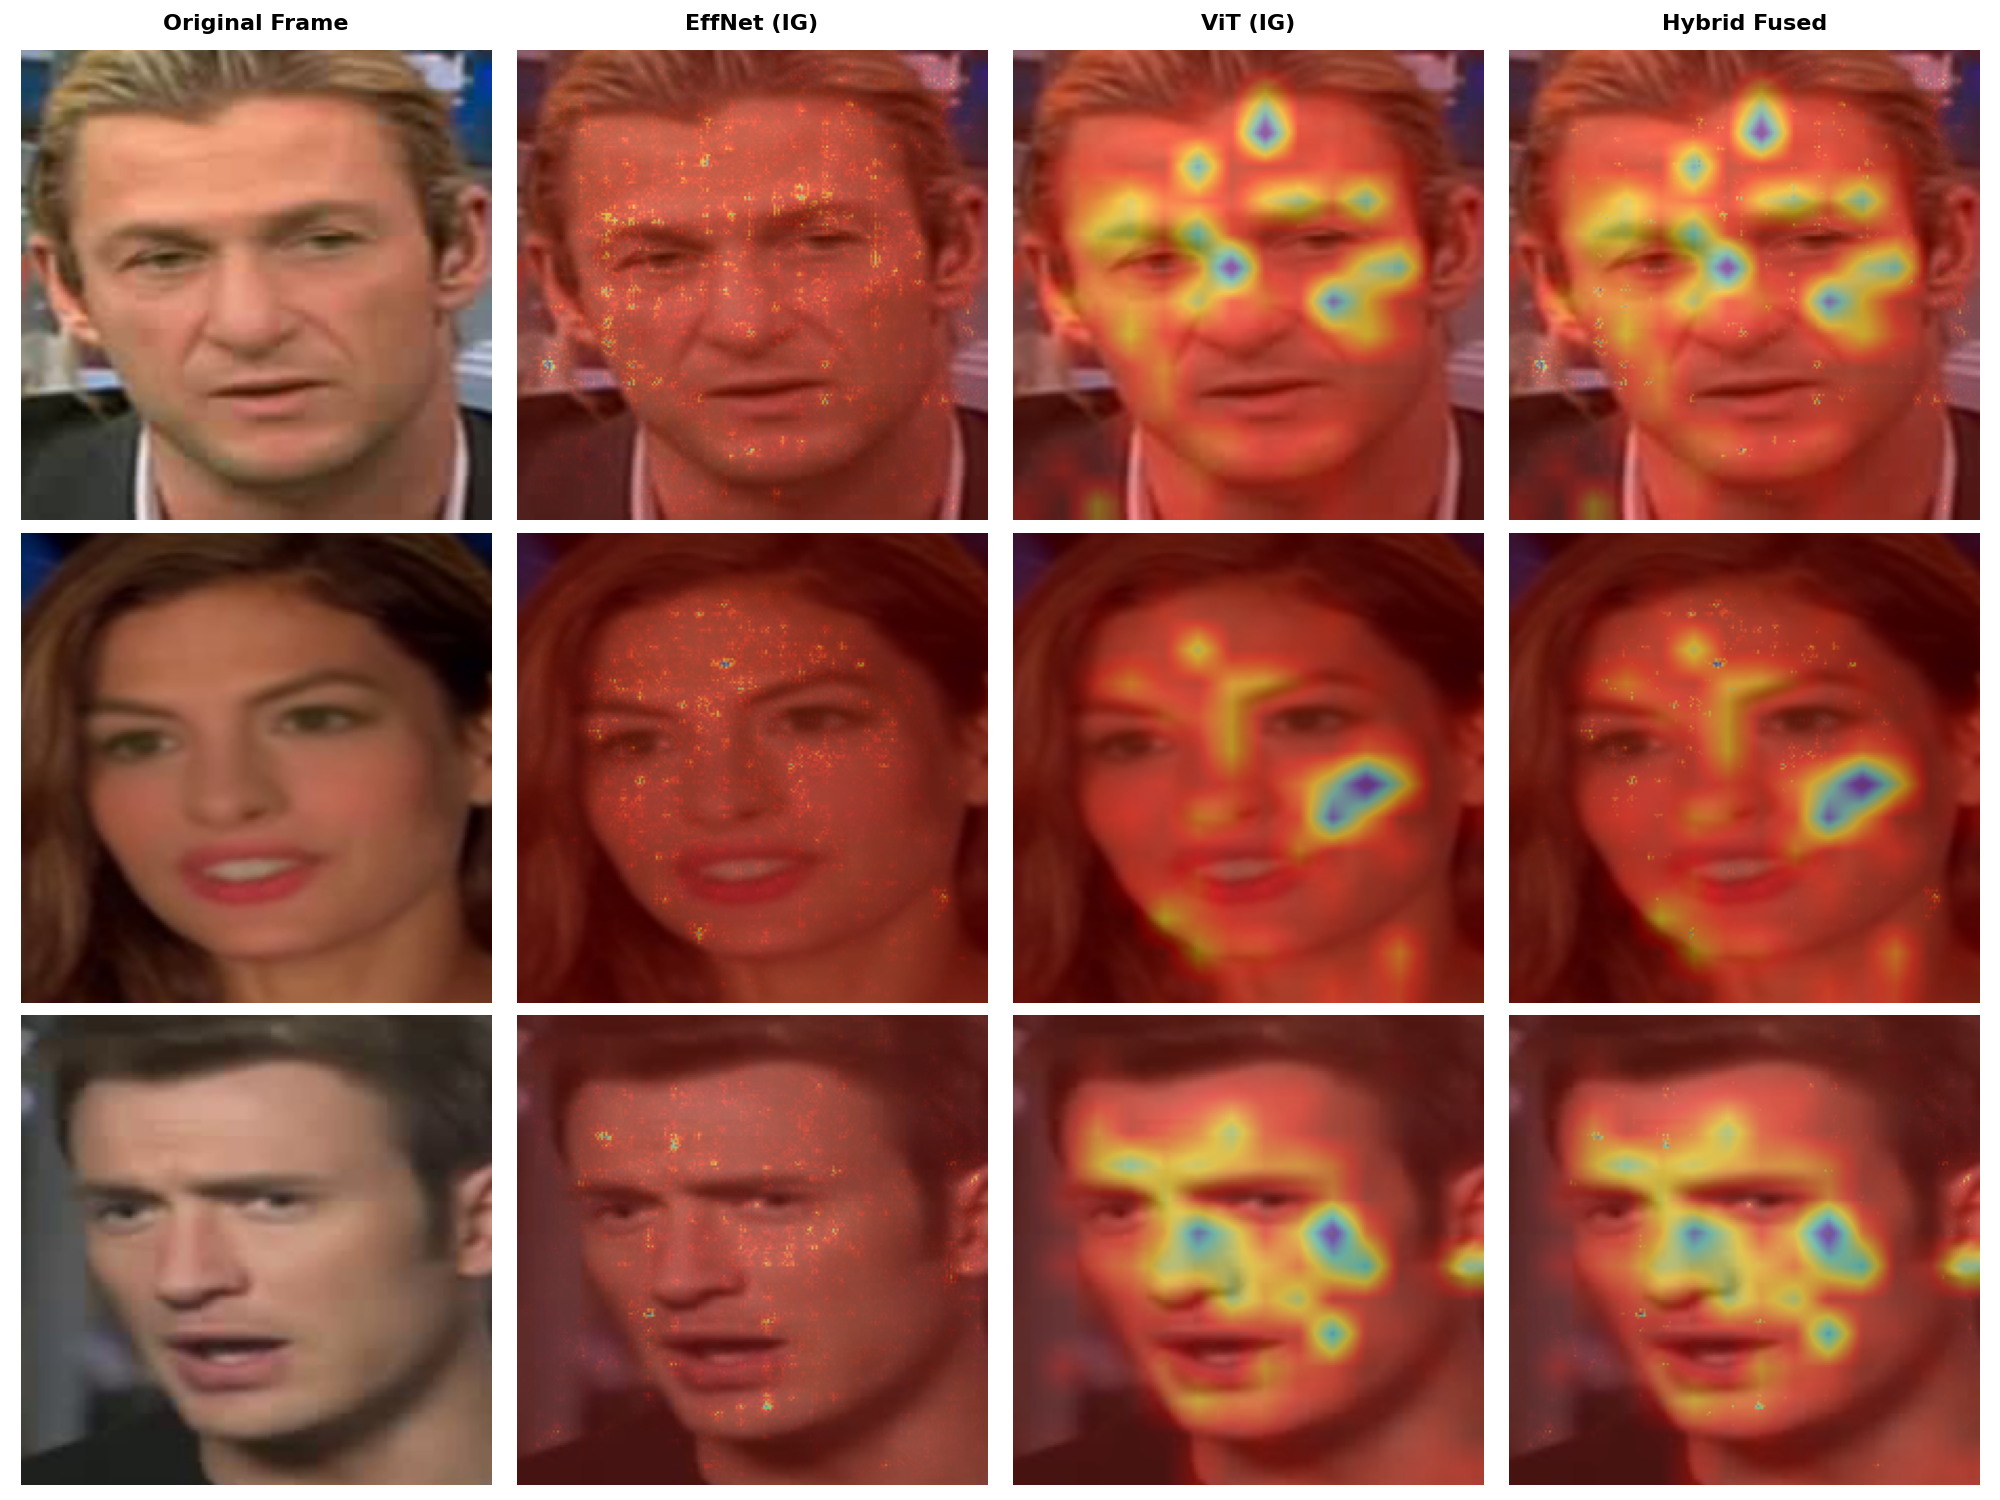

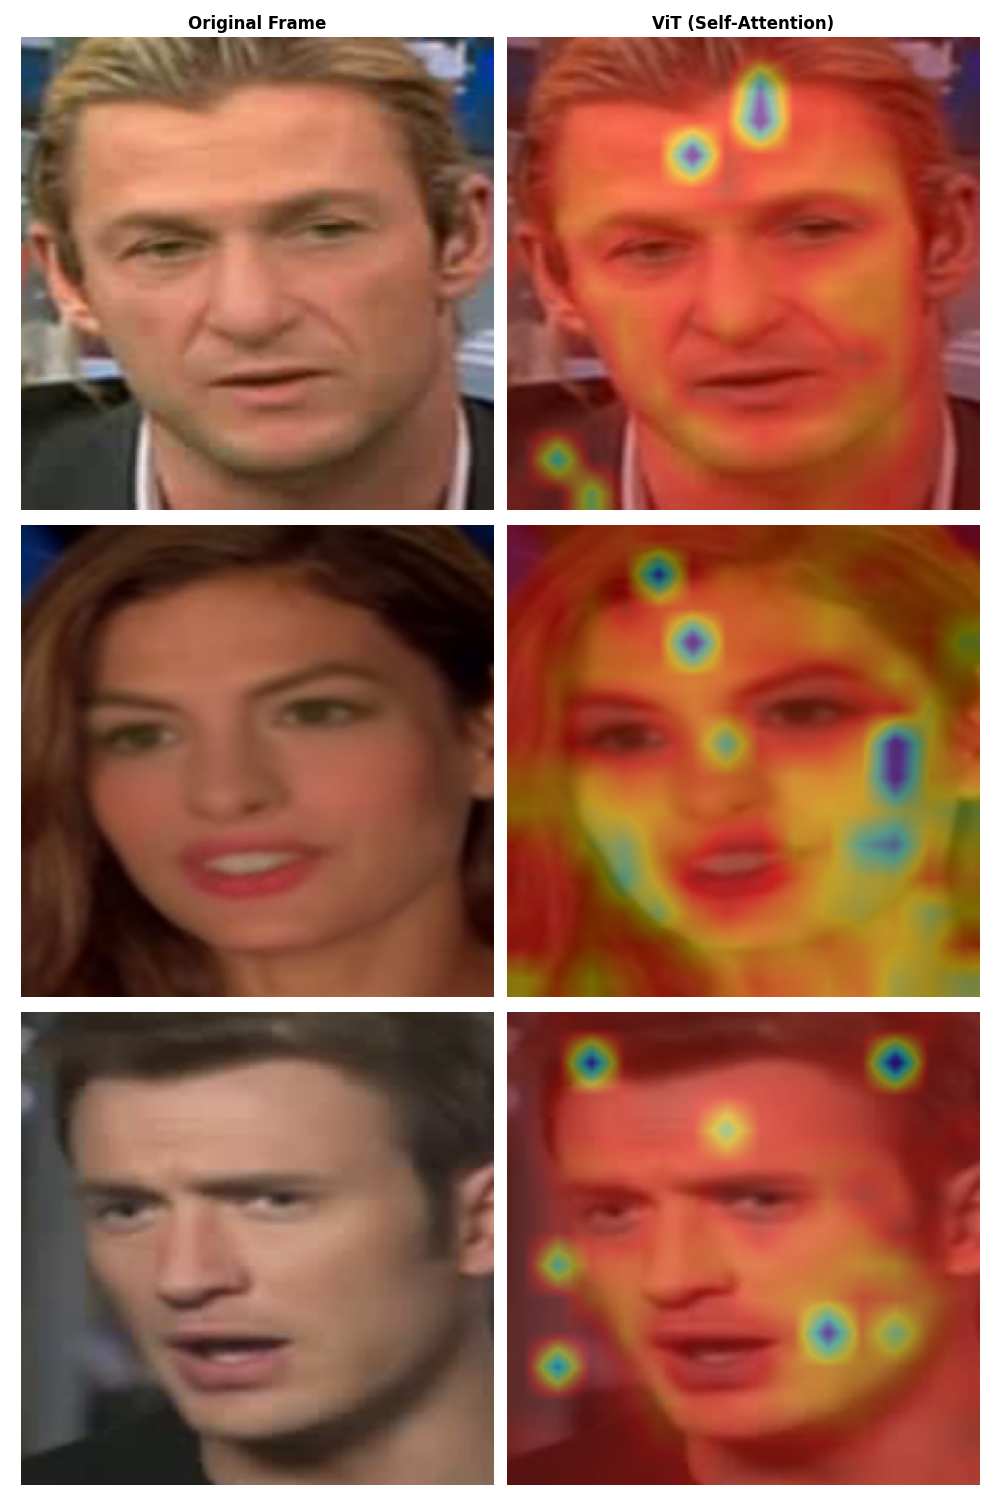

In [13]:
from IPython.display import Image, display
display(Image(filename='xai_2_gradcam_plus.png'))

display(Image(filename='xai_4_smoothgrad_grid.png'))
display(Image(filename='xai_5_ig_grid.png'))
display(Image(filename='xai_3_vit_attention.png'))